> # Апенко Константин Сергеевич
## 7группа, 3 курс
19.02.2026

> ## Вариант №27


> # ЛАБОРАТОРНАЯ РАБОТА № 1
> ## МОДЕЛИРОВАНИЕ ДИСКРЕТНОЙ СЛУЧАЙНОЙ ВЕЛИЧИНЫ 


1.	Разработать алгоритм моделирования заданной дискретной случайной величины и программно его реализовать.
2.	Провести тестовую проверку созданного генератора:
•	получить оценку математического ожидания генерируемой случайной величины и сравнить ее с математическим ожиданием заданной;
•	получить оценку дисперсии генерируемой случайной величины и сравнить ее с дисперсией заданной величины;
•	проверить гипотезу о соответствии генерируемой случайной величины заданному распределению по критерию 2;
•	построить графики заданной функции распределения случайной величины и функции распределения, полученной по сгенерированной выборке.


Рассматривается гипергеометрическое распределение:

$$P(X=x)=\frac{\binom{R}{x}\binom{N-R}{m-x}}{\binom{N}{m}}, \quad x=0,1,...,\min(R,m)$$

# Алгоритм моделирования гипергеометрической случайной величины

1. **Задаем параметры распределения**:
   - N — размер генеральной совокупности
   - R — количество "успешных" элементов
   - m — размер выборки
   - sample_size — количество генерируемых значений

2. **Вычисляем теоретические вероятности** для всех возможных значений X:
  

3. **Генерируем выборку** из гипергеометрического распределения (`np.random.hypergeometric`).

4. **Считаем эмпирические характеристики**:
   - Математическое ожидание: среднее выборки
   - Дисперсию: выборочную дисперсию

5. **Сравниваем с теоретическими значениями**, полученными по формуле распределения.

6. **Проверяем гипотезу χ²**:

7. **Строим графики функций распределения**:
   - Теоретическая функция распределения 
   - Эмпирическая функция распределения

8. **Составляем таблицу распределения** 

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt



## Задание параметров

In [2]:
N = 50 # размер генеральной совокупности
R = 20  # число "успешных" элементов
m = 10  # размер выборки
sample_size = 10000 # размер выборки для моделирования


## Теоретическое распределение

In [3]:
def comb(n, k): # биномиальнкоэффициент
    return math.comb(n, k)

def hypergeom_p(x):
    return comb(R, x) * comb(N - R, m - x) / comb(N, m) # Теоретическая вероятность

x_values = list(range(0, min(R, m) + 1)) # Список всех возможных значений X
p_values = [hypergeom_p(x) for x in x_values] # Теоретические вероятности


## Моделирование выборки

In [4]:
sample = np.random.hypergeometric(R, N - R, m, sample_size) # Используем встроенную генерацию гипергеометрического распределения

emp_mean = np.mean(sample)
emp_var = np.var(sample, ddof=1)

theor_mean = m * R / N
theor_var = m * R / N * (1 - R / N) * (N - m) / (N - 1)

emp_mean, theor_mean, emp_var, theor_var

print("Математическое ожидание:")
print(f" Теоретическое: {theor_mean:.4f}")
print(f" Эмпирическое: {emp_mean:.4f}\n")

print("Дисперсия:")
print(f" Теоретическая: {theor_var:.4f}")
print(f" Эмпирическая: {emp_var:.4f}\n")


Математическое ожидание:
 Теоретическое: 4.0000
 Эмпирическое: 3.9971

Дисперсия:
 Теоретическая: 1.9592
 Эмпирическая: 1.9649



Эмпирические оценки близки к теоретическим => генератор работает корректно.

## Проверка гипотезы χ²

In [5]:
obs_counts = [np.sum(sample == x) for x in x_values]

# Ожидаемое количество по формуле P(X=x)
exp_counts = [sample_size * p for p in p_values]

# Статистика χ² (наглядно)
chi2_stat = sum((o - e)**2 / e for o, e in zip(obs_counts, exp_counts))
print("Проверка гипотезы χ²:")
print(f" Статистика χ²: {chi2_stat:.4f}")
print(" Критическую область можно оценить по таблице χ² с df = len(x_values)-1")
if chi2_stat < 16.919:  # критическое значение χ² для df=9 и α=0.05
    print(" Вывод: гипотеза о соответствии генератора заданному распределению принимается!!! УРА")
else:
    print(" Вывод: гипотеза отвергается")



Проверка гипотезы χ²:
 Статистика χ²: 8.7612
 Критическую область можно оценить по таблице χ² с df = len(x_values)-1
 Вывод: гипотеза о соответствии генератора заданному распределению принимается!!! УРА


Теоретическое математическое ожидание: 

E[X]=m⋅R/N

Эмпирическое (генерируемое) 

E^[X]=среднее по выборке

## Теоретическая функция распределения

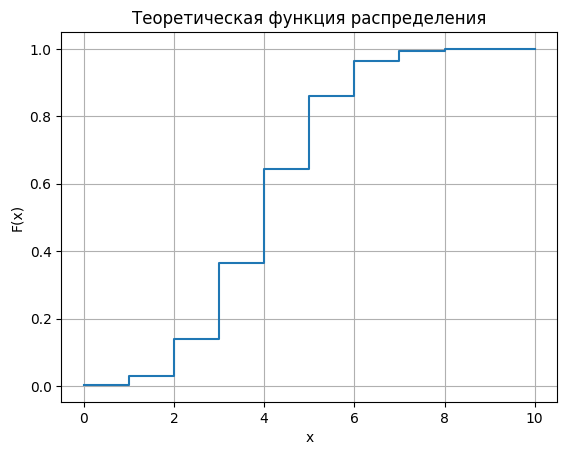

In [6]:
cdf_theor = np.cumsum(p_values)
plt.figure()
plt.step(x_values, cdf_theor, where='post')
plt.title('Теоретическая функция распределения')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.grid(True)
plt.show()


## Эмпирическая функция распределения

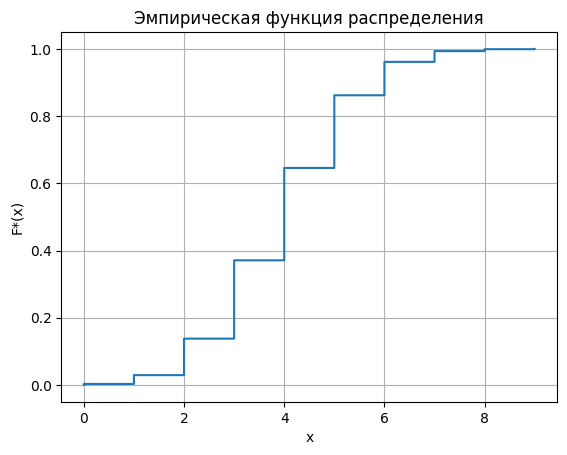

In [7]:
sorted_sample = np.sort(sample)
ecdf = np.arange(1, sample_size + 1) / sample_size

plt.figure()
plt.step(sorted_sample, ecdf, where='post')
plt.title('Эмпирическая функция распределения')
plt.xlabel('x')
plt.ylabel('F*(x)')
plt.grid(True)
plt.show()


In [8]:
import pandas as pd
df = pd.DataFrame({
    "x": x_values,
    "P(X=x) Теоретическое": p_values,
    "Количество в выборке": obs_counts,
    "P*(X=x) Эмпирическое": np.array(obs_counts)/sample_size
})
df

,x,P(X=x) Теоретическое,Количество в выборке,P*(X=x) Эмпирическое
0,0,0.002925,30,0.0030
1,1,0.027856,262,0.0262
2,2,0.108258,1086,0.1086
3,3,0.225930,2331,0.2331
4,4,0.280059,2749,0.2749
5,5,0.215085,2162,0.2162
6,6,0.103406,995,0.0995
7,7,0.030639,320,0.0320
8,8,0.005334,57,0.0057
9,9,0.000491,8,0.0008
